In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
x_train.shape

(60000, 784)

In [ ]:
x_test.shape

(10000, 784)

In [ ]:
y_train.shape

(60000, 10)

In [ ]:
y_test.shape

(10000, 10)

##L1 regularization

In [ ]:
model_l1 = tf.keras.Sequential([
    layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l1(1e-4),
                 input_shape=(784,)),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l1(1e-4)),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_l1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_l1 = model_l1.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8486 - loss: 1.1703 - val_accuracy: 0.9630 - val_loss: 0.5021
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9548 - loss: 0.4948 - val_accuracy: 0.9730 - val_loss: 0.3827
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9679 - loss: 0.3777 - val_accuracy: 0.9742 - val_loss: 0.3234
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9725 - loss: 0.3141 - val_accuracy: 0.9755 - val_loss: 0.2830
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9762 - loss: 0.2686 - val_accuracy: 0.9772 - val_loss: 0.2485
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9777 - loss: 0.2419 - val_accuracy: 0.9790 - val_loss: 0.2207
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9813 - loss: 0.2082 - val_accuracy: 0.9807 - val_loss: 0.2059
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9815 - loss: 0.1975 - val_accuracy: 0

In [ ]:
test_loss, test_acc = model_l1.evaluate(x_test, y_test, verbose=0)

print(f"L1 Regularization Test Accuracy: {test_acc:.4f}")


L1 Regularization Test Accuracy: 0.9789


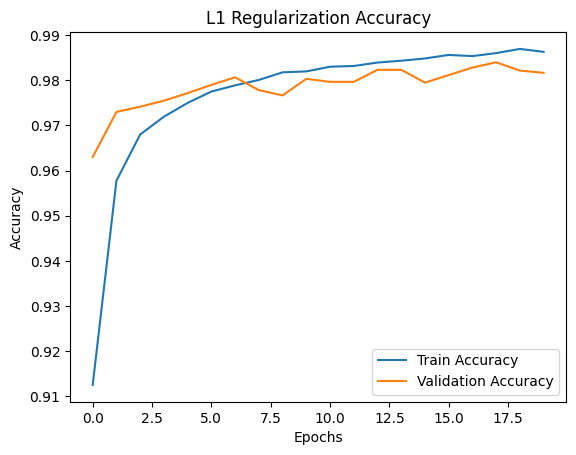

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_l1.history['accuracy'], label='Train Accuracy')
plt.plot(history_l1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('L1 Regularization Accuracy')
plt.show()


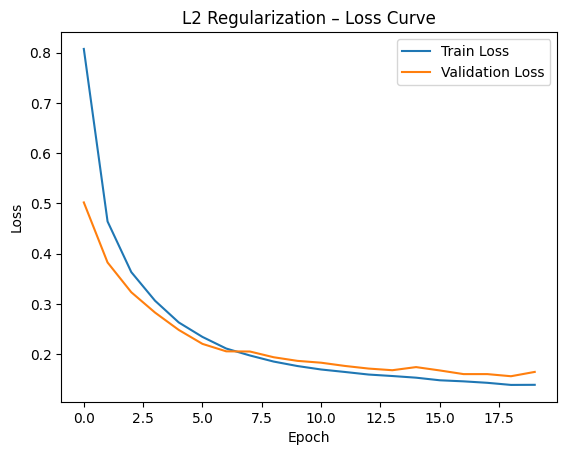

In [ ]:
plt.plot(history_l1.history['loss'], label='Train Loss')
plt.plot(history_l1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('L2 Regularization – Loss Curve')
plt.legend()
plt.show()


##L2

In [ ]:
model_l2 = tf.keras.Sequential([
    layers.Dense(
        256,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4),
        input_shape=(784,)
    ),
    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.Dense(10, activation='softmax')
])


In [ ]:
model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_l2 = model_l2.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8476 - loss: 0.5866 - val_accuracy: 0.9665 - val_loss: 0.1670
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9636 - loss: 0.1670 - val_accuracy: 0.9723 - val_loss: 0.1445
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9753 - loss: 0.1287 - val_accuracy: 0.9758 - val_loss: 0.1266
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9834 - loss: 0.1030 - val_accuracy: 0.9775 - val_loss: 0.1252
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9875 - loss: 0.0898 - val_accuracy: 0.9782 - val_loss: 0.1204
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9884 - loss: 0.0840 - val_accuracy: 0.9768 - val_loss: 0.1236
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9899 - loss: 0.0788 - val_accuracy: 0.9843 - val_loss: 0.1036
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9928 - loss: 0.0711 - val_accuracy: 0

In [ ]:
test_loss, test_acc = model_l2.evaluate(x_test, y_test, verbose=0)
print(f"L2 Regularization Test Accuracy: {test_acc:.4f}")

L2 Regularization Test Accuracy: 0.9790


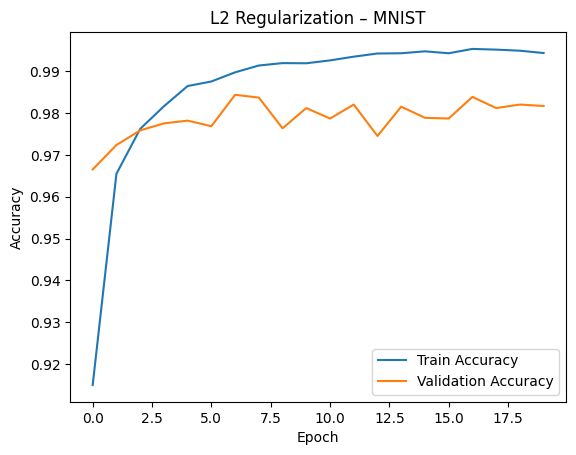

In [ ]:
plt.plot(history_l2.history['accuracy'], label='Train Accuracy')
plt.plot(history_l2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('L2 Regularization – MNIST')
plt.legend()
plt.show()


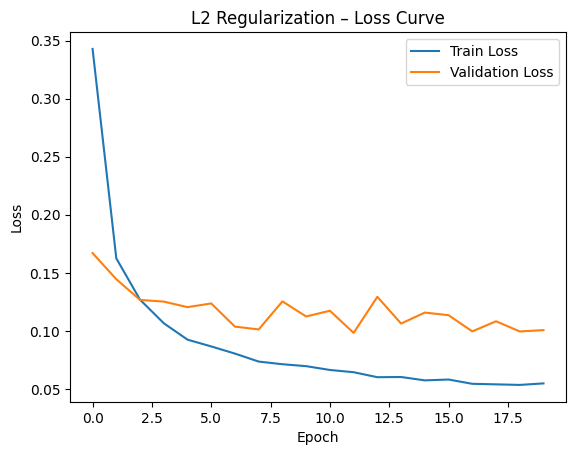

In [ ]:
plt.plot(history_l2.history['loss'], label='Train Loss')
plt.plot(history_l2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('L2 Regularization – Loss Curve')
plt.legend()
plt.show()


##Batch Normalization Model

In [ ]:
model_bn = tf.keras.Sequential([
    layers.Dense(256, input_shape=(784,), use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(128, use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(10, activation='softmax')
])

In [ ]:
model_bn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_bn = model_bn.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8776 - loss: 0.4203 - val_accuracy: 0.9718 - val_loss: 0.1000
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9753 - loss: 0.0853 - val_accuracy: 0.9733 - val_loss: 0.0875
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9850 - loss: 0.0516 - val_accuracy: 0.9758 - val_loss: 0.0802
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9894 - loss: 0.0346 - val_accuracy: 0.9777 - val_loss: 0.0726
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9930 - loss: 0.0239 - val_accuracy: 0.9783 - val_loss: 0.0765
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9951 - loss: 0.0182 - val_accuracy: 0.9808 - val_loss: 0.0664
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9959 - loss: 0.0150 - val_accuracy: 0.9795 - val_loss: 0.0803
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9958 - loss: 0.0144 - val_accuracy: 0

In [ ]:
test_loss, test_acc = model_bn.evaluate(x_test, y_test, verbose=0)
print(f"Batch Normalization Test Accuracy: {test_acc:.4f}")

Batch Normalization Test Accuracy: 0.9827


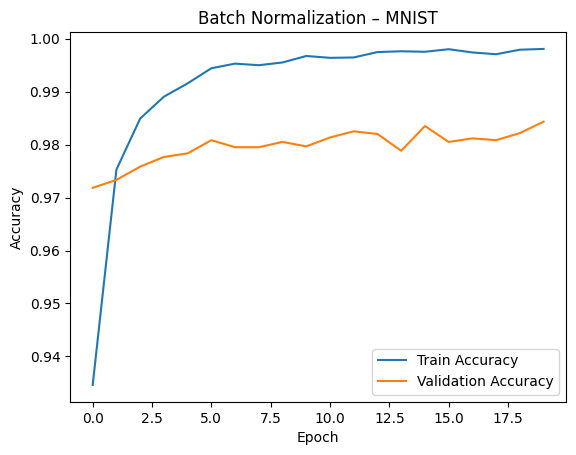

In [ ]:
plt.plot(history_bn.history['accuracy'], label='Train Accuracy')
plt.plot(history_bn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Batch Normalization – MNIST')
plt.legend()
plt.show()


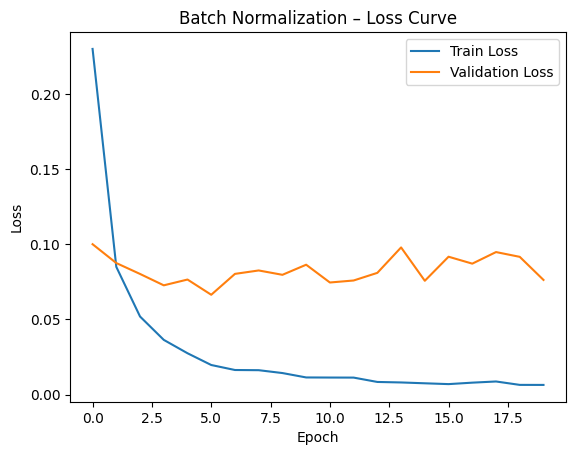

In [ ]:
plt.plot(history_bn.history['loss'], label='Train Loss')
plt.plot(history_bn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Batch Normalization – Loss Curve')
plt.legend()
plt.show()

## Dropout


In [ ]:
model_dropout = tf.keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])


In [ ]:
model_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_do = model_dropout.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7035 - loss: 0.9196 - val_accuracy: 0.9573 - val_loss: 0.1489
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9176 - loss: 0.2799 - val_accuracy: 0.9682 - val_loss: 0.1059
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9405 - loss: 0.2092 - val_accuracy: 0.9752 - val_loss: 0.0923
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9482 - loss: 0.1767 - val_accuracy: 0.9777 - val_loss: 0.0788
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9552 - loss: 0.1529 - val_accuracy: 0.9790 - val_loss: 0.0743
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9595 - loss: 0.1337 - val_accuracy: 0.9807 - val_loss: 0.0732
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9637 - loss: 0.1206 - val_accuracy: 0.9793 - val_loss: 0.0685
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9653 - loss: 0.1186 - val_accuracy: 0.

In [ ]:
test_loss, test_acc = model_dropout.evaluate(x_test, y_test, verbose=0)
print(f"Dropout Test Accuracy: {test_acc:.4f}")


Dropout Test Accuracy: 0.9817


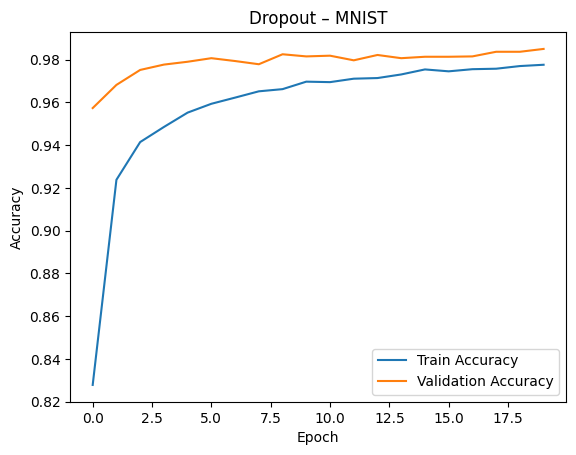

In [ ]:
plt.plot(history_do.history['accuracy'], label='Train Accuracy')
plt.plot(history_do.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Dropout – MNIST')
plt.legend()
plt.show()


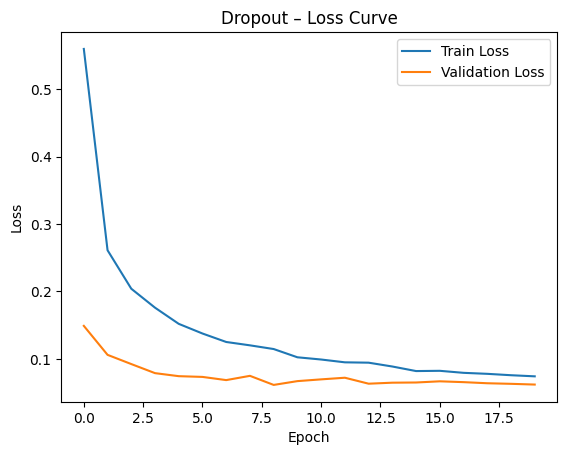

In [ ]:
plt.plot(history_do.history['loss'], label='Train Loss')
plt.plot(history_do.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Dropout – Loss Curve')
plt.legend()
plt.show()


## Elastic net


In [ ]:
l1_val = 1e-5
l2_val = 1e-4

model_en = tf.keras.Sequential([
    layers.Dense(
        256,
        activation='relu',
        kernel_regularizer=regularizers.l1_l2(l1=l1_val, l2=l2_val),
        input_shape=(784,)
    ),
    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l1_l2(l1=l1_val, l2=l2_val)
    ),
    layers.Dense(10, activation='softmax')
])


In [ ]:
model_en.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history_en = model_en.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8508 - loss: 0.6543 - val_accuracy: 0.9663 - val_loss: 0.2294
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9662 - loss: 0.2218 - val_accuracy: 0.9717 - val_loss: 0.1972
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9763 - loss: 0.1780 - val_accuracy: 0.9735 - val_loss: 0.1803
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9810 - loss: 0.1561 - val_accuracy: 0.9793 - val_loss: 0.1624
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9856 - loss: 0.1380 - val_accuracy: 0.9805 - val_loss: 0.1563
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9886 - loss: 0.1245 - val_accuracy: 0.9823 - val_loss: 0.1466
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9888 - loss: 0.1192 - val_accuracy: 0.9798 - val_loss: 0.1458
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9904 - loss: 0.1129 - val_accuracy: 0

In [ ]:
test_loss, test_acc = model_en.evaluate(x_test, y_test, verbose=0)
print(f"Elastic Net (L1+L2) Test Accuracy: {test_acc:.4f}")


Elastic Net (L1+L2) Test Accuracy: 0.9822


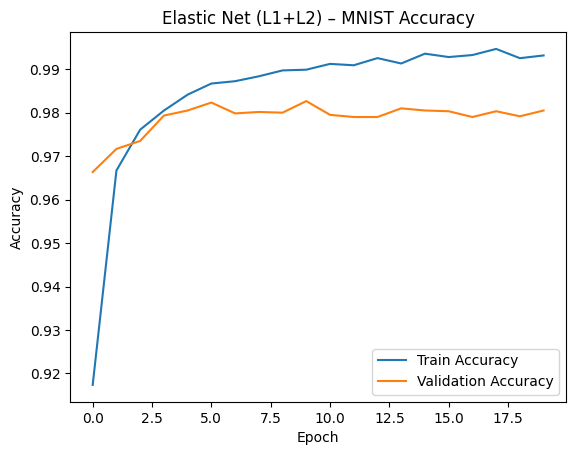

In [ ]:
plt.plot(history_en.history['accuracy'], label='Train Accuracy')
plt.plot(history_en.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Elastic Net (L1+L2) – MNIST Accuracy')
plt.legend()
plt.show()


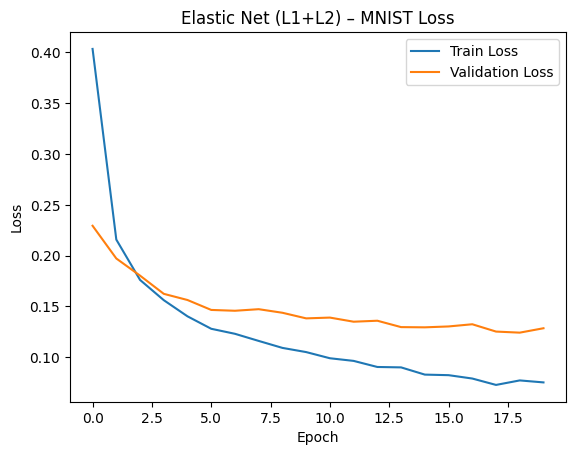

In [ ]:
plt.plot(history_en.history['loss'], label='Train Loss')
plt.plot(history_en.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Elastic Net (L1+L2) – MNIST Loss')
plt.legend()
plt.show()


**Done**

/-\ |-|